In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dtwpair import BaseDtwPair
from dtwpair import BruteforceDtwPair
from dtwpair import SlidingWindowDtwPair
from dtwpair import SakoeChibaDtwPair
from dtwpair import SchibaSlidingWindowDtwPair
import numpy as np
import matplotlib.pyplot as plt
from dtwpair.utils.dtw_distance import AbsoluteDtwDistance, SquaredDtwDistance
from dtwpair.utils.timer import Timer
import pickle

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, LogLocator

import pandas as pd


/home/akenforcer/anaconda3/envs/dtw/lib/python3.11/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [3]:
mapping = {
    'BruteforceDtwPair': 'Brute Force',
    'SlidingWindowDtwPair': 'SP (Ours)',
    'SakoeChibaDtwPair': 'Sakoe Chiba',
    'SchibaSlidingWindowDtwPair': 'SP with Sakoe Chiba (Ours)'
}

In [13]:
def plot_length_vs_runtime(ax):
    Y = []
    Y_labels = []
    for j in range(10):
        with open(f'benchmark3/results_{j}.pkl', 'rb') as f:
            rrrr = pickle.load(f)
        
        X = [rrrr[i][0] for i in range(len(rrrr))]
        _Y = []
        _Y_labels = []
        for k in rrrr[0][1].keys():
            _Y.append([rrrr[i][1][k]['elapsed'] for i in range(len(rrrr))])
            _Y_labels.append(k)

        Y.append(_Y)
        Y_labels = _Y_labels

    X = np.array(X)  # Shape: (Trials,)
    Y = np.array(Y)  # Shape: (Trials, Methods, Size)
    Y = np.transpose(Y, (1, 2, 0))  # Shape: (Methods, Size, Trials)

    res = {}

    for method_idx, label in enumerate(Y_labels):
        mean_runtime = np.mean(Y[method_idx], axis=1)
        std_error = np.std(Y[method_idx], axis=1) / np.sqrt(Y.shape[-1])
        ci_95 = 1.96 * std_error  # 95% confidence interval
        yerr = [ci_95, ci_95]
        _X = X
        res[label] = {
            'X': _X,
            'mean_runtime': mean_runtime,
            'std_error': std_error,
            'ci_95': ci_95
        }
        ax.errorbar(_X, mean_runtime, yerr=yerr, fmt='-o', capsize=5, label=mapping.get(label, label))

    ax.set_yscale('log', base=10)
    ax.yaxis.set_minor_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{x:.0f}'))
    ax.tick_params(axis='y', which='minor', labelsize=8)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10))
    ax.xaxis.set_major_locator(plt.MultipleLocator(1000))
    ax.set_xlabel('Time Series Length')
    ax.set_ylabel('Run time (seconds)')
    ax.set_title(f'Time Series Length vs Run time ({Y.shape[-1]} Trials)')
    ax.legend()
    ax.grid(True, which='both', ls='--', alpha=0.5)

    return res


In [14]:
def plot_length_vs_window_size(ax):
    Y = []
    Y_labels = []
    for j in range(10):
        with open(f'benchmark3w/results_{j}.pkl', 'rb') as f:
            rrrr = pickle.load(f)
        
        X = [rrrr[i][0] for i in range(len(rrrr))]
        _Y = []
        _Y_labels = []
        for k in rrrr[0][1].keys():
            _Y.append([rrrr[i][1][k]['elapsed'] for i in range(len(rrrr))])
            _Y_labels.append(k)

        Y.append(_Y)
        Y_labels = _Y_labels

    X = np.array(X)  # Shape: (Trials,)
    Y = np.array(Y)  # Shape: (Trials, Methods, Size)
    Y = np.transpose(Y, (1, 2, 0))  # Shape: (Methods, Size, Trials)

    res = {}
    
    for method_idx, label in enumerate(Y_labels):
        mean_runtime = np.mean(Y[method_idx], axis=1)
        std_error = np.std(Y[method_idx], axis=1) / np.sqrt(Y.shape[-1])
        ci_95 = 1.96 * std_error  # 95% confidence interval
        yerr = [ci_95, ci_95]
        _X = X
        res[label] = {
            'X': _X,
            'mean_runtime': mean_runtime,
            'std_error': std_error,
            'ci_95': ci_95
        }
        ax.errorbar(_X, mean_runtime, yerr=yerr, fmt='-o', capsize=5, label=mapping.get(label, label))

    ax.set_yscale('log', base=10)
    ax.yaxis.set_minor_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{x:.0f}'))
    ax.tick_params(axis='y', which='minor', labelsize=8)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10))
    ax.set_xlabel(f'Window Size (% of Time Series Length)')
    ax.set_ylabel('Runtime (seconds)')
    ax.set_title(f'Window Size vs Runtime ({Y.shape[-1]} Trials)')
    ax.legend()
    ax.grid(True, which='both', ls='--', alpha=0.5)

    return res


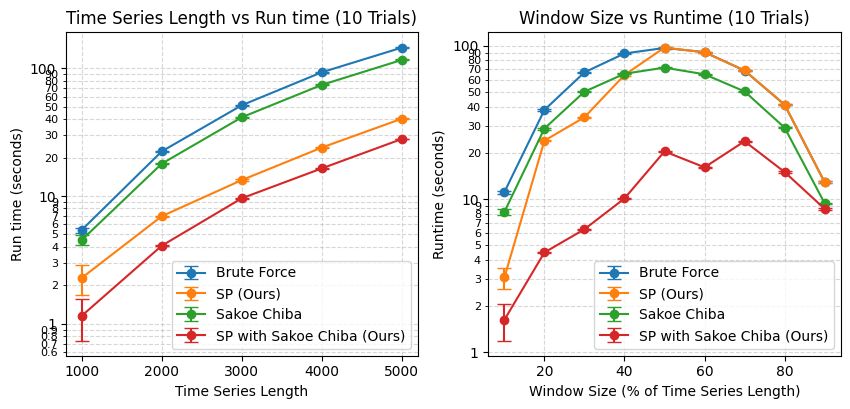

In [15]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 4.2))

res0 = plot_length_vs_runtime(axs[0])
res1 = plot_length_vs_window_size(axs[1])

In [16]:
res0

{'BruteforceDtwPair': {'X': array([1000, 2000, 3000, 4000, 5000]),
  'mean_runtime': array([  5.41656628,  22.33256907,  51.29638579,  92.95988774,
         144.99561162]),
  'std_error': array([0.12121287, 0.12551716, 0.28924582, 0.44033339, 0.75886115]),
  'ci_95': array([0.23757723, 0.24601364, 0.56692181, 0.86305344, 1.48736786])},
 'SlidingWindowDtwPair': {'X': array([1000, 2000, 3000, 4000, 5000]),
  'mean_runtime': array([ 2.28379312,  6.94338531, 13.32025907, 23.93906438, 40.27384479]),
  'std_error': array([0.3083306 , 0.04037565, 0.0810875 , 0.15060985, 0.29602517]),
  'ci_95': array([0.60432799, 0.07913627, 0.1589315 , 0.29519531, 0.58020933])},
 'SakoeChibaDtwPair': {'X': array([1000, 2000, 3000, 4000, 5000]),
  'mean_runtime': array([  4.51696255,  17.89145544,  41.29667323,  74.07121089,
         116.17264345]),
  'std_error': array([0.20376388, 0.10667221, 0.19931779, 0.40830968, 0.6269495 ]),
  'ci_95': array([0.39937721, 0.20907753, 0.39066286, 0.80028697, 1.22882101])

In [20]:
def plot_noise_vs_runtime(ax, limit=1):
    Y = []
    Y_labels = []
    all_f1 = []

    for j in range(10):
        with open(f'benchmark3r/results_{j}.pkl', 'rb') as f:
            rrrr = pickle.load(f)
        
        X = [rrrr[i][0] for i in range(len(rrrr))]
        _Y = []
        _Y_labels = []
        for k in rrrr[0][1].keys():
            _Y.append([rrrr[i][1][k]['elapsed'] for i in range(len(rrrr))])
            _Y_labels.append(k)

        Y.append(_Y)
        Y_labels = _Y_labels


        for i in range(len(rrrr)):
            for k, r in rrrr[i][1].items():
                # print(r['f1'])
                
                all_f1.append({
                    'f1': r['f1'],
                    'method': k,
                    'trial': j,
                    'motif_weight': rrrr[i][0]
                })

    X = np.array(X)  # Shape: (Trials,)
    Y = np.array(Y)  # Shape: (Trials, Methods, Size)
    Y = np.transpose(Y, (1, 2, 0))  # Shape: (Methods, Size, Trials)

    all_f1 = pd.DataFrame(all_f1)

    res = {}

    for method_idx, label in enumerate(Y_labels):
        _Y = Y[method_idx][::-1]
        _X = (1 - X)[::-1]

        _Y = _Y[_X <= limit]
        _X = _X[_X <= limit]

        mean_runtime = np.mean(_Y, axis=1)
        std_error = np.std(_Y, axis=1) / np.sqrt(Y.shape[-1])
        ci_95 = 1.96 * std_error  # 95% confidence interval
        yerr = [ci_95, ci_95]

        res[label] = {
            'X': _X,
            'mean_runtime': mean_runtime,
            'std_error': std_error,
            'ci_95': ci_95
        }
        
        ax.errorbar(_X, mean_runtime, yerr=yerr, fmt='-o', capsize=5, label=mapping[label])

    ax.set_yscale('log', base=10)
    ax.yaxis.set_minor_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}' if x < 1 else f'{x:.0f}'))
    ax.tick_params(axis='y', which='minor', labelsize=8)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10))
    ax.set_xlabel('Noise Weight')
    ax.set_ylabel('Run Time (seconds)')
    ax.set_title(f'Noise vs Run Time ({Y.shape[-1]} Trials)')
    ax.legend()
    ax.grid(True, which='both', ls='--', alpha=0.5)

    return res

In [21]:
def plot_robust(ax, limit=1):
    Y = []
    Y_labels = []
    all_f1 = []

    for j in range(10):
        with open(f'benchmark3r/results_{j}.pkl', 'rb') as f:
            rrrr = pickle.load(f)
        
        X = [rrrr[i][0] for i in range(len(rrrr))]
        _Y = []
        _Y_labels = []
        for k in rrrr[0][1].keys():
            _Y.append([rrrr[i][1][k]['elapsed'] for i in range(len(rrrr))])
            _Y_labels.append(k)

        Y.append(_Y)
        Y_labels = _Y_labels


        for i in range(len(rrrr)):
            for k, r in rrrr[i][1].items():
                # print(r['f1'])
                
                all_f1.append({
                    'f1': r['f1'],
                    'method': k,
                    'trial': j,
                    'motif_weight': rrrr[i][0]
                })

    X = np.array(X)  # Shape: (Trials,)
    Y = np.array(Y)  # Shape: (Trials, Methods, Size)
    Y = np.transpose(Y, (1, 2, 0))  # Shape: (Methods, Size, Trials)

    all_f1 = pd.DataFrame(all_f1)

    res = {}

    for method_idx, label in enumerate(Y_labels):
        metric: pd.DataFrame = all_f1[all_f1.method == label] \
            .drop(columns=['method', 'trial']) \
            .groupby(['motif_weight']).agg(['mean', 'std'])['f1']

        metric.index = 1 - metric.index

        metric = metric.loc[metric.index <= limit]

        # print(metric)
        metric.sort_index(inplace=True)

        yerr = [1.96 * metric['std'], 1.96 * metric['std']]

        res[label] = {
            'X': metric.index,
            'mean': metric['mean'],
            'std': metric['std'],
            'ci_95': yerr
        }

        plt.errorbar(metric.index, metric['mean'], yerr=yerr, fmt='-o', capsize=5, label=mapping[label])
    
    ax.set_xlabel('Noise Weight')
    ax.set_ylabel('F1 Score')
    ax.set_title('Noise vs F1 Score')
    ax.legend()
    ax.grid(True, which='both', ls='--', alpha=0.5)

    return res

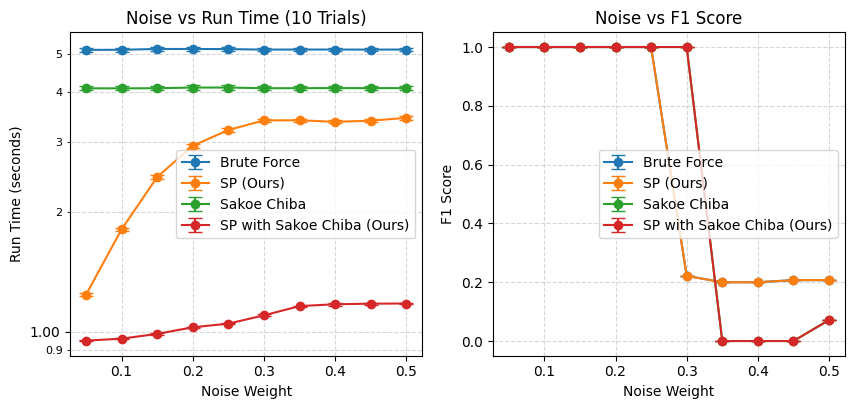

In [22]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 4.2))

res2 = plot_noise_vs_runtime(axs[0], limit=0.5)
res3 = plot_robust(axs[1], limit=0.5)

In [23]:
res2

{'BruteforceDtwPair': {'X': array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ]),
  'mean_runtime': array([5.10641687, 5.1100528 , 5.13370242, 5.13397193, 5.13013568,
         5.11512859, 5.11741121, 5.11663957, 5.11497231, 5.11713121]),
  'std_error': array([0.02577327, 0.02665077, 0.0272854 , 0.02968757, 0.02912753,
         0.02758558, 0.02606494, 0.02767922, 0.02588321, 0.02664042]),
  'ci_95': array([0.05051561, 0.0522355 , 0.05347939, 0.05818763, 0.05708995,
         0.05406774, 0.05108729, 0.05425127, 0.05073108, 0.05221522])},
 'SlidingWindowDtwPair': {'X': array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ]),
  'mean_runtime': array([1.23846662, 1.80758083, 2.44686146, 2.93197546, 3.21110671,
         3.39666805, 3.39741871, 3.36792278, 3.38880634, 3.44598296]),
  'std_error': array([0.00584278, 0.00856541, 0.01303391, 0.01615797, 0.01670368,
         0.01589112, 0.01613306, 0.01671027, 0.01622282, 0.01714438]),
  'ci_95': array([0.01145185, 0.016

In [24]:
res3

{'BruteforceDtwPair': {'X': Index([0.04999999999999993, 0.09999999999999987,  0.1499999999999999,
         0.19999999999999996,  0.2499999999999999, 0.29999999999999993,
         0.34999999999999987,  0.3999999999999999, 0.44999999999999996,
                         0.5],
        dtype='float64', name='motif_weight'),
  'mean': motif_weight
  0.05    1.000000
  0.10    1.000000
  0.15    1.000000
  0.20    1.000000
  0.25    1.000000
  0.30    0.221429
  0.35    0.200000
  0.40    0.200000
  0.45    0.207143
  0.50    0.207143
  Name: mean, dtype: float64,
  'std': motif_weight
  0.05    0.0
  0.10    0.0
  0.15    0.0
  0.20    0.0
  0.25    0.0
  0.30    0.0
  0.35    0.0
  0.40    0.0
  0.45    0.0
  0.50    0.0
  Name: std, dtype: float64,
  'ci_95': [motif_weight
   0.05    0.0
   0.10    0.0
   0.15    0.0
   0.20    0.0
   0.25    0.0
   0.30    0.0
   0.35    0.0
   0.40    0.0
   0.45    0.0
   0.50    0.0
   Name: std, dtype: float64,
   motif_weight
   0.05    0.0
   0.10   